In [32]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [33]:
from config import dir_config, main_config
from src.utils import classification_utils

processed_dir = Path(dir_config.data.processed)
metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)

In [34]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(metadata)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


#### Change in UPDRS, TREMOR SCORE, BRADY_SCORE and BRADY_VS_TREMOR score post medication

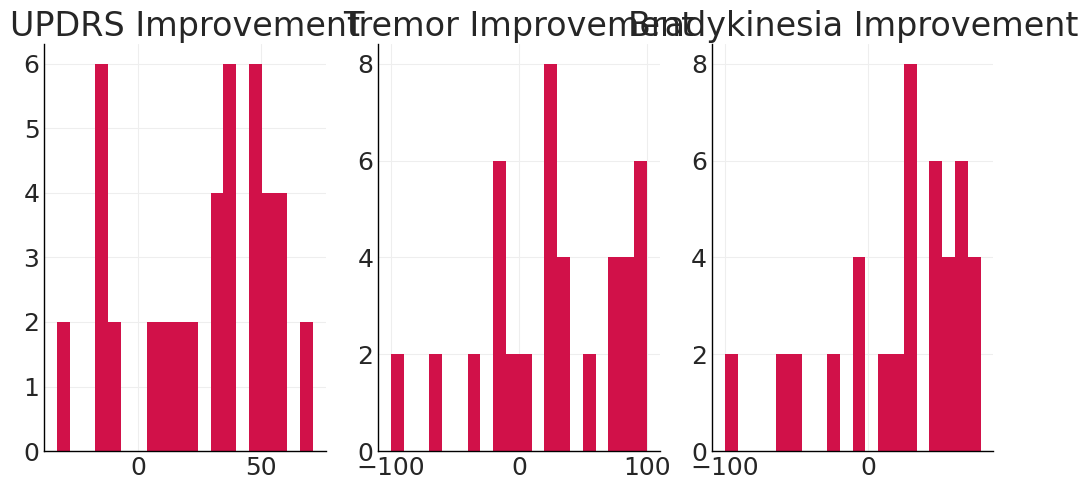

In [35]:
# Plot histogram
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
metadata["UPDRS_improvement"].hist(bins=20, ax=ax[0])
ax[0].set_title("UPDRS Improvement")
metadata["tremor_improvement"].hist(bins=20, ax=ax[1])
ax[1].set_title("Tremor Improvement")
metadata["bradykinesia_improvement"].hist(bins=20, ax=ax[2])
ax[2].set_title("Bradykinesia Improvement")
plt.tight_layout()
plt.show()


### Effect of medication on all scores and groups

In [36]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

metrics = {
    "UPDRS": "UPDRS",
    "Tremor Score": "tremor_score",
    "Bradykinesia Score": "bradykinesia_score",
    "Tremor/Brady Ratio": "trem_by_brady",
}

# collect all results first so we can apply FDR correction across all tests
results = []
for group in ["pd", "tremor", "brady"]:
    for metric_label, col in metrics.items():
        off = metadata.iloc[grp_indices[f"{group}_off"]][col].dropna().values
        on  = metadata.iloc[grp_indices[f"{group}_on"]][col].dropna().values
        n = min(len(off), len(on))
        off, on = off[:n], on[:n]
        stat, p = stats.wilcoxon(off, on, alternative="greater")
        results.append({"group": group, "metric": metric_label, "off": off, "on": on, "W": stat, "p": p})

# BH-FDR correction across all 12 tests
_, p_fdr, _, _ = multipletests([r["p"] for r in results], method="fdr_bh")
for r, p_adj in zip(results, p_fdr):
    r["p_fdr"] = p_adj

print(f"{'Group':<10} {'Metric':<22} {'Off (mean±sd)':<22} {'On (mean±sd)':<22} {'W':<8} {'p-raw':<10} {'p-FDR':<10} {'Sig'}")
print("-" * 110)
for r in results:
    off, on = r["off"], r["on"]
    sig = "***" if r["p_fdr"] < 0.001 else "**" if r["p_fdr"] < 0.01 else "*" if r["p_fdr"] < 0.05 else "ns"
    print(f"{r['group']:<10} {r['metric']:<22} "
          f"{off.mean():.2f} ± {off.std():.2f}        "
          f"{on.mean():.2f} ± {on.std():.2f}        "
          f"{r['W']:<8.1f} {r['p']:<10.4f} {r['p_fdr']:<10.4f} {sig}")

Group      Metric                 Off (mean±sd)          On (mean±sd)           W        p-raw      p-FDR      Sig
--------------------------------------------------------------------------------------------------------------
pd         UPDRS                  20.41 ± 7.46        14.64 ± 7.76        220.5    0.0011     0.0133     *
pd         Tremor Score           0.61 ± 0.34        0.39 ± 0.37        209.5    0.0035     0.0133     *
pd         Bradykinesia Score     0.74 ± 0.38        0.51 ± 0.32        207.0    0.0044     0.0133     *
pd         Tremor/Brady Ratio     1.19 ± 1.26        1.01 ± 0.99        146.0    0.2723     0.3268     ns
tremor     UPDRS                  19.18 ± 6.21        14.18 ± 8.30        56.5     0.0176     0.0391     *
tremor     Tremor Score           0.84 ± 0.24        0.48 ± 0.43        62.0     0.0034     0.0133     *
tremor     Bradykinesia Score     0.59 ± 0.29        0.49 ± 0.30        47.5     0.1064     0.1419     ns
tremor     Tremor/Brady Ratio    

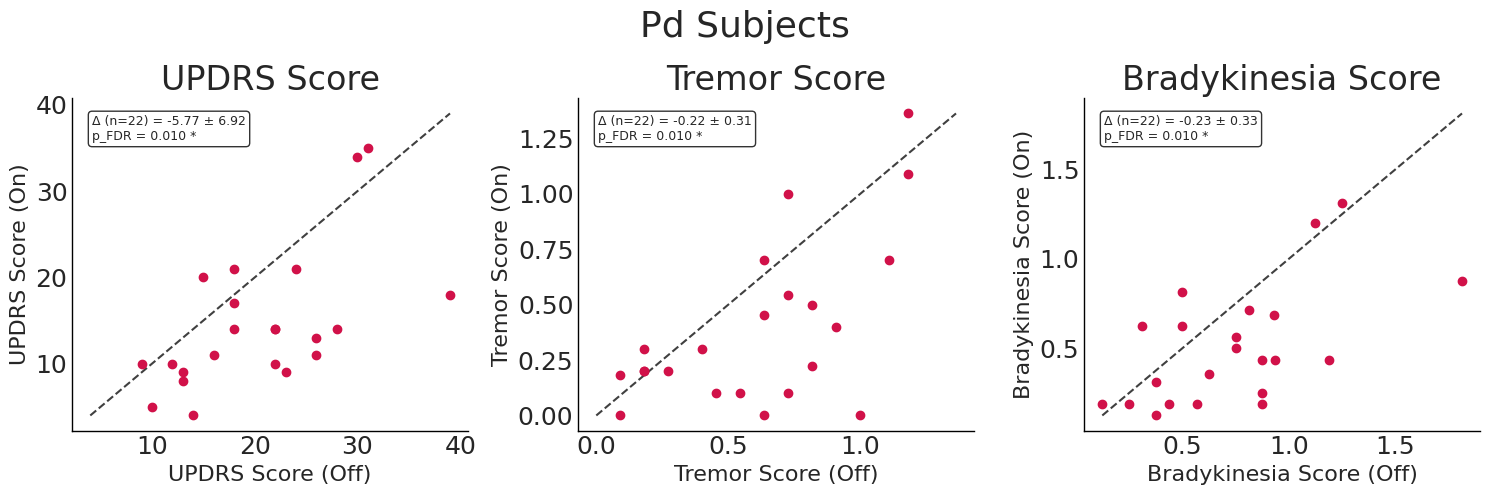

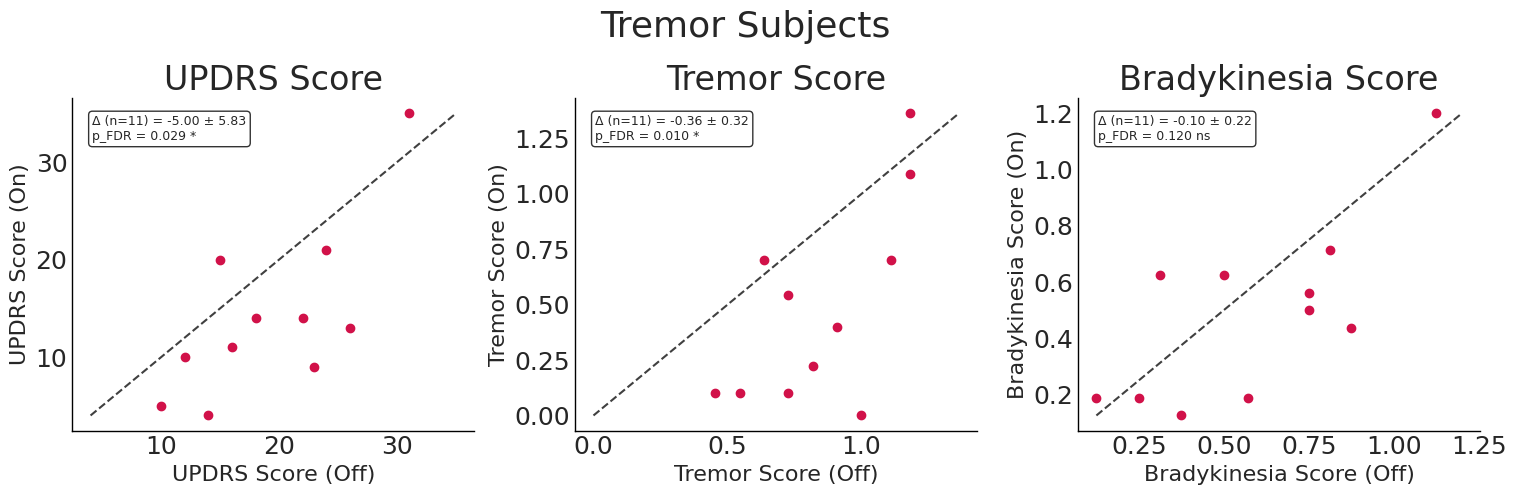

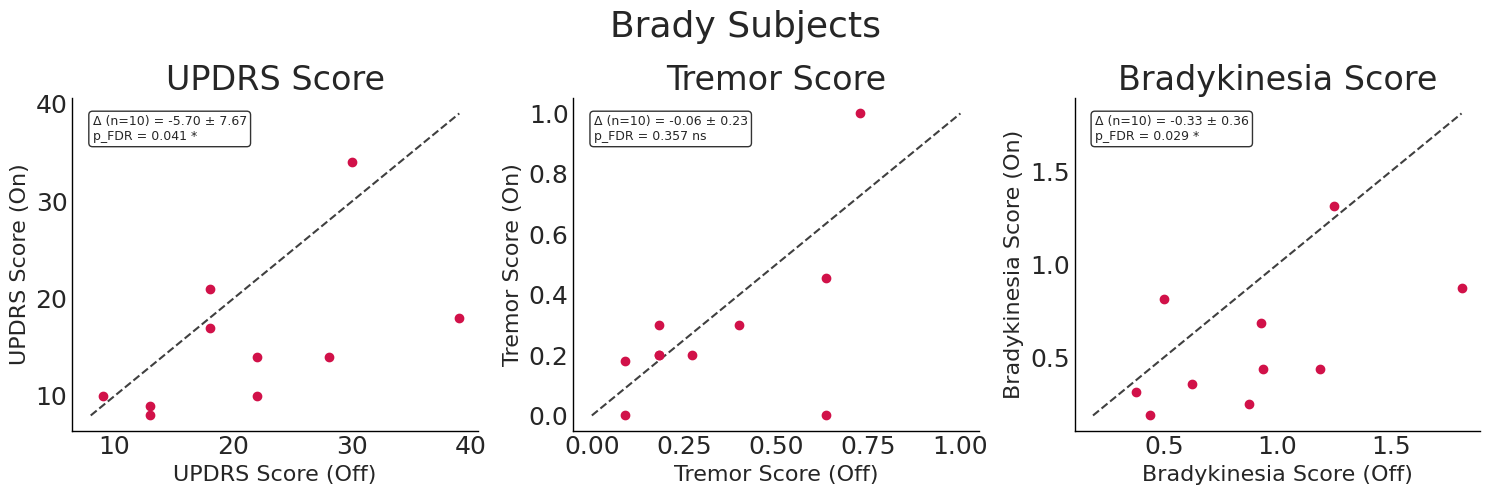

In [37]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

groups = ["pd", "tremor", "brady"]
score_cols   = ["UPDRS", "tremor_score", "bradykinesia_score"]
score_labels = ["UPDRS Score", "Tremor Score", "Bradykinesia Score"]

wilcoxon_results = {}
for group in groups:
    for col in score_cols:
        off = metadata.iloc[grp_indices[f"{group}_off"]][col].dropna().values
        on  = metadata.iloc[grp_indices[f"{group}_on"]][col].dropna().values
        n = min(len(off), len(on))
        off, on = off[:n], on[:n]
        W, p = stats.wilcoxon(off, on, alternative="greater")
        diff = on - off
        wilcoxon_results[(group, col)] = {"W": W, "p": p, "n": n, "mean_change": diff.mean(), "std_change": diff.std()}

_, p_fdr, _, _ = multipletests([wilcoxon_results[k]["p"] for k in wilcoxon_results], method="fdr_bh")
for k, p_adj in zip(wilcoxon_results, p_fdr):
    wilcoxon_results[k]["p_fdr"] = p_adj

def _sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

def _annotate(ax, r):
    ax.text(0.05, 0.95,
            f"Δ (n={r['n']}) = {r['mean_change']:.2f} ± {r['std_change']:.2f}\np_FDR = {r['p_fdr']:.3f} {_sig(r['p_fdr'])}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

for group in groups:
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, (col, label) in enumerate(zip(score_cols, score_labels)):
        off_vals = metadata.iloc[grp_indices[f"{group}_off"]][col]
        on_vals  = metadata.iloc[grp_indices[f"{group}_on"]][col]
        ax[i].scatter(off_vals, on_vals)
        lims = [min(off_vals.min(), on_vals.min()), max(off_vals.max(), on_vals.max())]
        ax[i].plot(lims, lims, "k--", alpha=0.75, zorder=0)
        ax[i].set_title(label)
        ax[i].set_xlabel(f"{label} (Off)")
        ax[i].set_ylabel(f"{label} (On)")
        _annotate(ax[i], wilcoxon_results[(group, col)])
    fig.suptitle(f"{group.capitalize()} Subjects", fontsize=26)
    plt.tight_layout()
    plt.show()

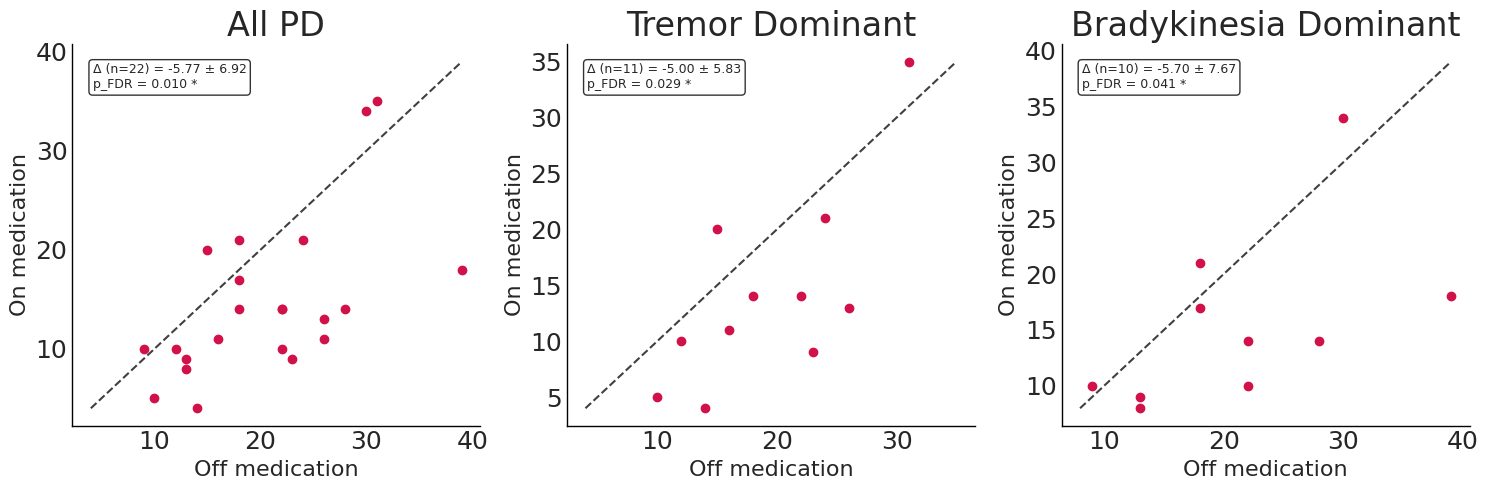

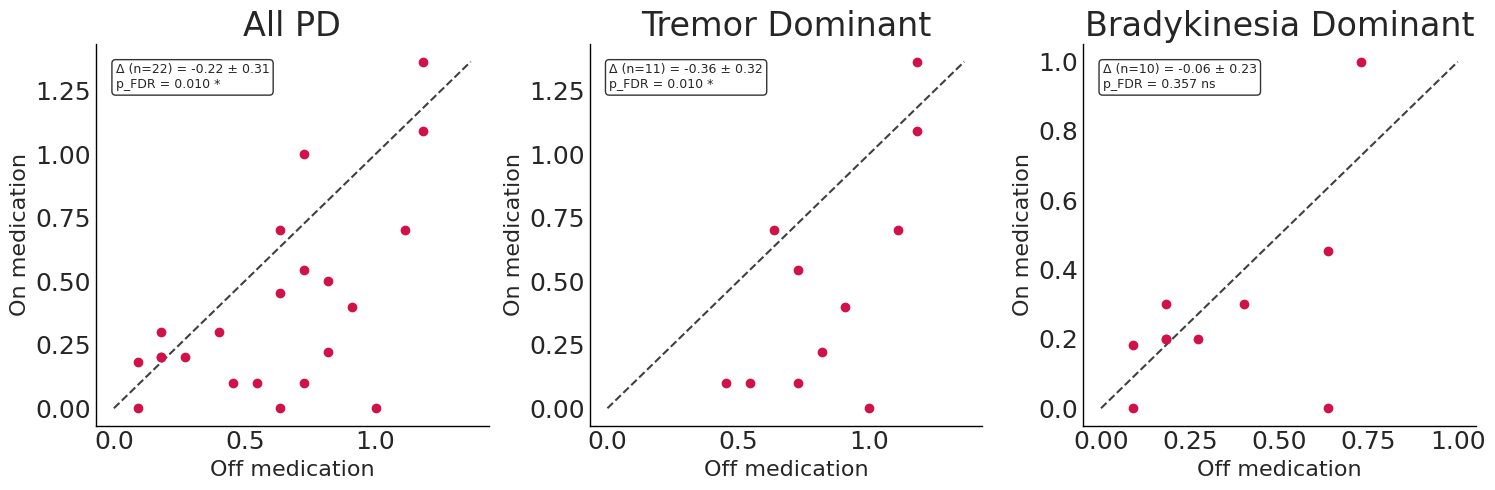

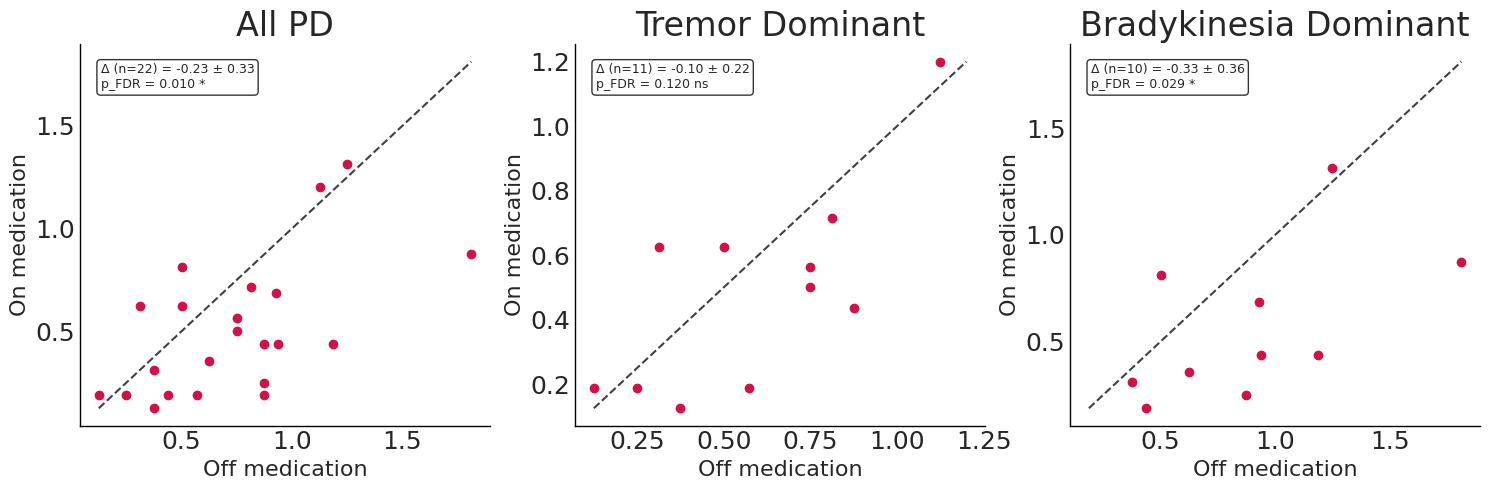

In [38]:
group_labels = {"pd": "All PD", "tremor": "Tremor Dominant", "brady": "Bradykinesia Dominant"}

for col, score_label in zip(score_cols, score_labels):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, group in enumerate(groups):
        off_vals = metadata.iloc[grp_indices[f"{group}_off"]][col]
        on_vals  = metadata.iloc[grp_indices[f"{group}_on"]][col]
        ax[i].scatter(off_vals, on_vals)
        lims = [min(off_vals.min(), on_vals.min()), max(off_vals.max(), on_vals.max())]
        ax[i].plot(lims, lims, "k--", alpha=0.75, zorder=0)
        ax[i].set_title(group_labels[group])
        ax[i].set_xlabel("Off medication")
        ax[i].set_ylabel("On medication")
        _annotate(ax[i], wilcoxon_results[(group, col)])

    # fig.suptitle(score_label, fontsize=26)

    plt.tight_layout()
    plt.show()

### Time since Diagnosis and Explicitness

In [39]:
GROUP_ORDER = [("HC", "none"), ("tremor", "OFF"), ("tremor", "ON"), ("bradykinetic", "OFF"), ("bradykinetic", "ON")]

mean_diagnosis_time = {}
mean_explicitness = {}

for group in GROUP_ORDER:
    if group[0] == "HC":
        sub_df = metadata[metadata["is_pd"] == 0]
    else:
        sub_df = metadata[(metadata["treatment"] == group[1]) & (metadata["trem_vs_brady_type"] == group[0])]

    mean_diagnosis_time[group] = sub_df["years_since_diagnosis"].mean()
    mean_explicitness[group] = sub_df["explicitness"].mean()


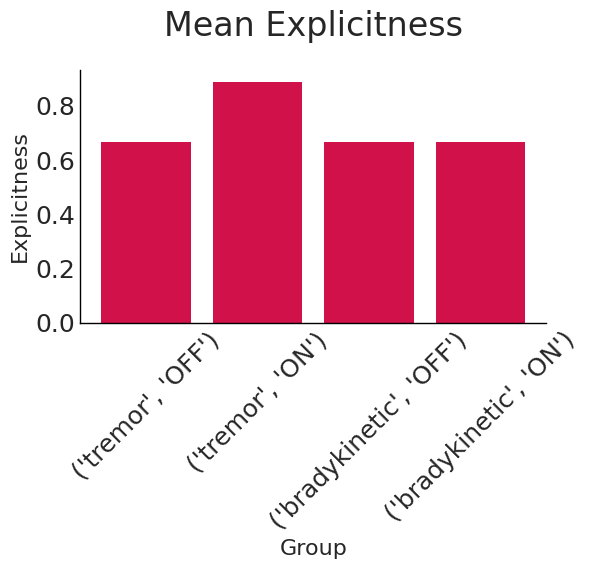

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
x2 = [str(k) for k in mean_explicitness.keys()]
y2 = [float(np.asarray(v).item()) for v in mean_explicitness.values()]

ax.bar(x2, y2)
ax.set_title("Mean Explicitness", y=1.1)
ax.set_xlabel("Group")
ax.set_ylabel("Explicitness")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

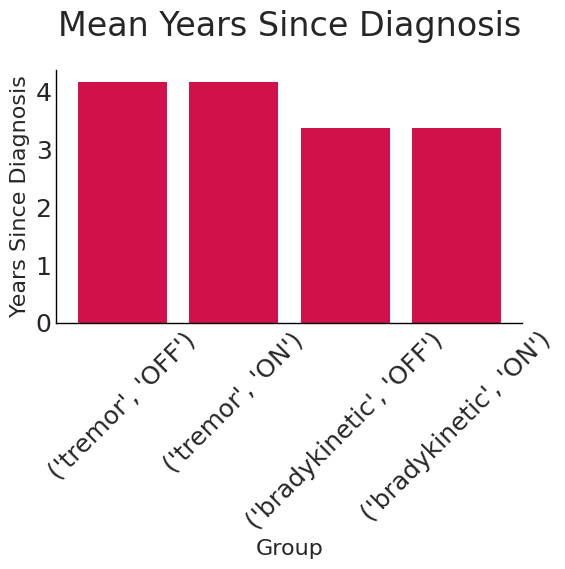

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# --- clean diagnosis time ---
x1 = [str(k) for k in mean_diagnosis_time.keys()]
y1 = [float(np.asarray(v).item()) for v in mean_diagnosis_time.values()]

ax.bar(x1, y1)
ax.set_title("Mean Years Since Diagnosis", y=1.1)
ax.set_xlabel("Group")
ax.set_ylabel("Years Since Diagnosis")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
